# LiDAR r3+blur → линейный blend Model + RIFE

**Маска:** только `spread_radius_fine=3` + `spread_blur_fine≈1` (без широкой zone).

**Blend:** где `lidar_trust ≥ mask_thr` → `α·model + (1−α)·rife`, иначе **RIFE**.

In [1]:
import json
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

REPO = Path(r"C:/Users/adel/Documents/GitHub/YA-")
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import importlib
import consensus_kit
importlib.reload(consensus_kit)
from consensus_kit import (
    ConsensusConfig,
    ConsensusDataset,
    default_config,
    discover_samples,
    make_split,
    load_consensus_model,
    psnr_uint8_np,
    tensor_to_hwc_rgb,
)
from lidar_density_mask import build_lidar_density, blend_model_rife_lidar, lidar_trust_for_sample

try:
    import cv2
except ImportError:
    cv2 = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)


cuda


## 1. CONFIG

In [2]:
CFG = default_config()
CFG.allowed_cameras = ("front", "rear")

# LiDAR: только r3 + лёгкий blur
CFG.lidar_zone_method = "spread"
CFG.lidar_spread_radius_fine = 3.0
CFG.lidar_spread_blur_fine = 1.0
CFG.lidar_spread_radius = 0.0
CFG.lidar_zone_min = 0.12

CKPT_PATH = REPO / "checkpoints_consensus" / "consensus_unet_best.pt"
USE_EMA = True

BLEND_ALPHA = 0.55          # вес модели в зоне лидара
MASK_THR = CFG.lidar_zone_min

PROBE_IDX = 0
PROBE_CAMERA = None         # "front" / "rear" / None

VAL_FRACTION = 0.16
VAL_SEED = 42
VAL_SUBSET = 0              # 0 = весь val; иначе первые N для быстрого прогона

print(f"lidar: r={CFG.lidar_spread_radius_fine} blur={CFG.lidar_spread_blur_fine}  thr={MASK_THR}")
print(f"blend α={BLEND_ALPHA}  ckpt={CKPT_PATH.is_file()}")


lidar: r=3.0 blur=1.0  thr=0.12
blend α=0.55  ckpt=True


## 2. Сэмпл + маска lidar_trust

2025-10-01_11_45_46_12_19_35_robb_1759310438799892000__000 front projected 554240
trust>thr: 100.0%


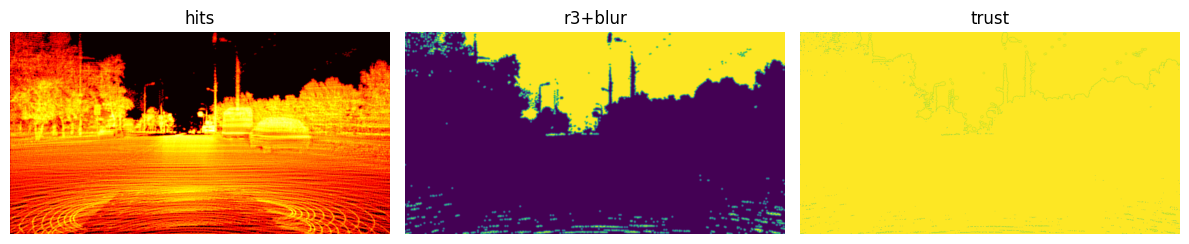

In [3]:
def pick_baked(cfg, idx=0, camera=None):
    out = []
    for baked in sorted(Path(cfg.baked_root).iterdir()):
        if not (baked / "meta.json").is_file():
            continue
        meta = json.loads((baked / "meta.json").read_text(encoding="utf-8"))
        cam = meta.get("camera")
        if cfg.allowed_cameras and cam not in cfg.allowed_cameras:
            continue
        if camera and cam != camera:
            continue
        src = Path(meta.get("source_dir", Path(cfg.dataset_root) / meta["sample_id"]))
        if (src / "input" / "lidar.npz").is_file():
            out.append(baked)
    if not out:
        raise FileNotFoundError("нет baked с lidar.npz")
    return out[idx % len(out)]


baked_dir = pick_baked(CFG, PROBE_IDX, PROBE_CAMERA)
meta = json.loads((baked_dir / "meta.json").read_text(encoding="utf-8"))
src = Path(meta.get("source_dir", Path(CFG.dataset_root) / meta["sample_id"]))
cam = meta["camera"]
hw = (CFG.image_h, CFG.image_w)

lm = build_lidar_density(
    src, cam, target_hw=hw,
    zone_method="spread",
    spread_radius_fine=CFG.lidar_spread_radius_fine,
    spread_blur_fine=CFG.lidar_spread_blur_fine,
    spread_radius=0,
    fine_only=True,
    zone_min=CFG.lidar_zone_min,
    spike_trust=1.0,
)
trust = lm["lidar_trust"]
print(meta["sample_id"], cam, "projected", lm["n_projected"])
print(f"trust>thr: {(trust >= MASK_THR).mean()*100:.1f}%")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
ax[0].imshow(np.log1p(lm["hits"]), cmap="hot"); ax[0].set_title("hits")
ax[1].imshow(lm["density_fine"], cmap="viridis", vmin=0, vmax=1); ax[1].set_title("r3+blur")
ax[2].imshow(trust, cmap="viridis", vmin=0, vmax=1); ax[2].set_title("trust")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()


## 3. Model + RIFE → blend по маске

In [4]:
if not CKPT_PATH.is_file():
    raise FileNotFoundError(f"Нет чекпоинта {CKPT_PATH}")

model, _ = load_consensus_model(CKPT_PATH, DEVICE, use_ema=USE_EMA, cfg=CFG)
model.eval()

ds = ConsensusDataset([baked_dir], CFG, augment=False)
batch = ds[0]
with torch.no_grad():
    inp = batch["inputs"].unsqueeze(0).to(DEVICE)
    msk = batch["effective_mask"].unsqueeze(0).to(DEVICE)
    base = batch["base_init"].unsqueeze(0).to(DEVICE)
    with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16, enabled=DEVICE.type == "cuda"):
        pred = model(inp, msk, base)["pred"].float()

model_rgb = tensor_to_hwc_rgb(pred)
rife_rgb = tensor_to_hwc_rgb(batch["rife_rgb"])
gt_rgb = tensor_to_hwc_rgb(batch["target"])

blended = blend_model_rife_lidar(model_rgb, rife_rgb, trust, alpha=BLEND_ALPHA, mask_thr=MASK_THR)

p_model = psnr_uint8_np(model_rgb, gt_rgb)
p_rife = psnr_uint8_np(rife_rgb, gt_rgb)
p_blend = psnr_uint8_np(blended, gt_rgb)
print(f"PSNR model={p_model:.2f}  RIFE={p_rife:.2f}  blend={p_blend:.2f}  (α={BLEND_ALPHA})")


PSNR model=20.43  RIFE=19.53  blend=20.65  (α=0.55)


## 4. Визуализация

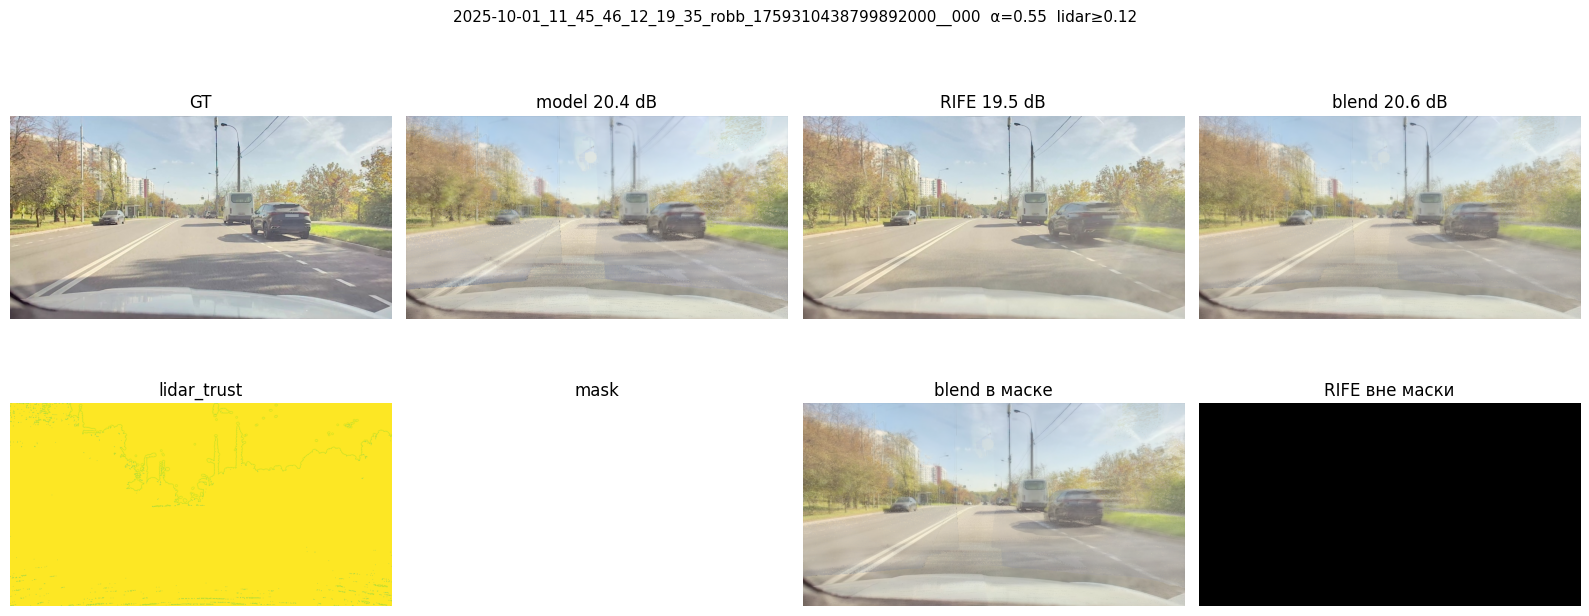

In [5]:
has = (trust >= MASK_THR)[..., None]

fig, ax = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle(f"{meta['sample_id']}  α={BLEND_ALPHA}  lidar≥{MASK_THR}", fontsize=11)

ax[0, 0].imshow(gt_rgb); ax[0, 0].set_title("GT")
ax[0, 1].imshow(model_rgb); ax[0, 1].set_title(f"model {p_model:.1f} dB")
ax[0, 2].imshow(rife_rgb); ax[0, 2].set_title(f"RIFE {p_rife:.1f} dB")
ax[0, 3].imshow(blended); ax[0, 3].set_title(f"blend {p_blend:.1f} dB")

ax[1, 0].imshow(trust, cmap="viridis", vmin=0, vmax=1); ax[1, 0].set_title("lidar_trust")
ax[1, 1].imshow(has[..., 0], cmap="gray", vmin=0, vmax=1); ax[1, 1].set_title("mask")
ax[1, 2].imshow(np.where(has, blended, 0)); ax[1, 2].set_title("blend в маске")
ax[1, 3].imshow(np.where(~has, rife_rgb, 0)); ax[1, 3].set_title("RIFE вне маски")
for a in ax.ravel():
    a.axis("off")
plt.tight_layout(); plt.show()


## 5. Перебор α (только в зоне лидара)

α → PSNR: 0.00:19.53, 0.10:19.82, 0.20:20.07, 0.30:20.30, 0.40:20.47, 0.50:20.60, 0.60:20.68, 0.70:20.70, 0.80:20.66, 0.90:20.57, 1.00:20.43
best α=0.70  PSNR=20.70


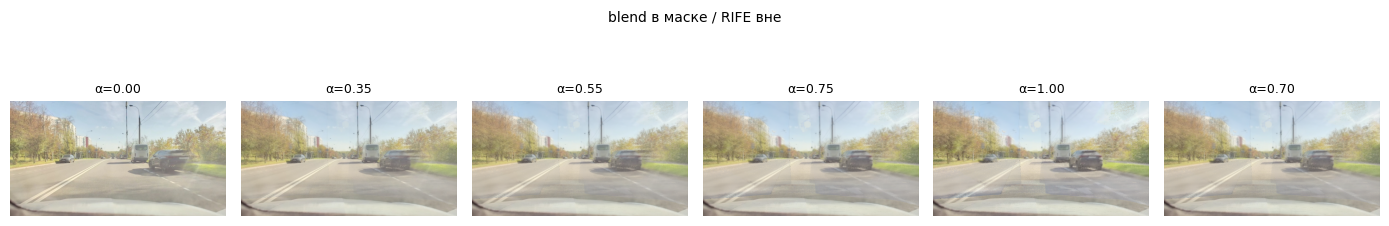

In [6]:
alphas = np.linspace(0, 1, 11)
psnrs = []
for a in alphas:
    out = blend_model_rife_lidar(model_rgb, rife_rgb, trust, alpha=float(a), mask_thr=MASK_THR)
    psnrs.append(psnr_uint8_np(out, gt_rgb))
best_i = int(np.argmax(psnrs))
print("α → PSNR:", ", ".join(f"{a:.2f}:{p:.2f}" for a, p in zip(alphas, psnrs)))
print(f"best α={alphas[best_i]:.2f}  PSNR={psnrs[best_i]:.2f}")

fig, ax = plt.subplots(1, 6, figsize=(14, 2.8))
for i, a in enumerate([0.0, 0.35, 0.55, 0.75, 1.0, alphas[best_i]]):
    out = blend_model_rife_lidar(model_rgb, rife_rgb, trust, alpha=float(a), mask_thr=MASK_THR)
    ax[i].imshow(out)
    ax[i].set_title(f"α={a:.2f}", fontsize=9)
    ax[i].axis("off")
plt.suptitle("blend в маске / RIFE вне", fontsize=10)
plt.tight_layout(); plt.show()


## 6. Val split (как в consensus_training)

Тот же `val_fraction=0.16`, `seed=42`, камеры front/rear.

In [7]:
ALL_SAMPLES = discover_samples(CFG)
_, VAL_PATHS = make_split(ALL_SAMPLES, VAL_FRACTION, VAL_SEED)
if VAL_SUBSET > 0:
    VAL_PATHS = VAL_PATHS[:VAL_SUBSET]
print(f"val: {len(VAL_PATHS)} / {len(ALL_SAMPLES)} samples")


val: 71 / 449 samples


## 7. Прогон val: model + RIFE + lidar_trust

Один проход inference на каждый val-сэмпл (долго ~1–2 мин на GPU для ~70 кадров).

In [8]:
HW = (CFG.image_h, CFG.image_w)
val_cache = []

for i, baked_dir in enumerate(VAL_PATHS):
    meta = json.loads((baked_dir / "meta.json").read_text(encoding="utf-8"))
    src = Path(meta.get("source_dir", Path(CFG.dataset_root) / meta["sample_id"]))
    cam = meta["camera"]
    trust = lidar_trust_for_sample(
        src, cam, HW,
        spread_radius_fine=CFG.lidar_spread_radius_fine,
        spread_blur_fine=CFG.lidar_spread_blur_fine,
        zone_min=CFG.lidar_zone_min,
    )
    ds = ConsensusDataset([baked_dir], CFG, augment=False)
    batch = ds[0]
    with torch.no_grad():
        inp = batch["inputs"].unsqueeze(0).to(DEVICE)
        msk = batch["effective_mask"].unsqueeze(0).to(DEVICE)
        base = batch["base_init"].unsqueeze(0).to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16, enabled=DEVICE.type == "cuda"):
            pred = model(inp, msk, base)["pred"].float()
    val_cache.append({
        "meta": meta,
        "model": tensor_to_hwc_rgb(pred),
        "rife": tensor_to_hwc_rgb(batch["rife_rgb"]),
        "gt": tensor_to_hwc_rgb(batch["target"]),
        "trust": trust,
    })
    if (i + 1) % 10 == 0 or i + 1 == len(VAL_PATHS):
        print(f"  {i+1}/{len(VAL_PATHS)}  {meta['sample_id'][:40]}...", flush=True)

b_model = np.mean([psnr_uint8_np(e["model"], e["gt"]) for e in val_cache])
b_rife = np.mean([psnr_uint8_np(e["rife"], e["gt"]) for e in val_cache])
print(f"val mean PSNR  model={b_model:.3f}  RIFE={b_rife:.3f}")


  10/71  2026-03-15_07_31_56_09_59_27_targi_17735...


  20/71  2025-11-02_18_06_30_19_04_02_susana_1762...


  30/71  2025-10-19_16_01_37_16_29_15_hilma_17608...


  40/71  2026-03-12_16_55_35_17_53_26_soan_177332...


  50/71  2025-10-18_11_02_41_12_08_49_robb_176077...


  60/71  2025-10-01_11_45_46_12_19_35_robb_175931...


  70/71  2026-03-15_12_13_41_12_38_31_targi_17735...


  71/71  2025-10-12_11_46_05_13_19_22_natelio_176...


val mean PSNR  model=21.060  RIFE=21.329


## 8. Перебор α на всём val

In [9]:
ALPHAS = np.round(np.linspace(0, 1, 21), 2)
mean_psnr = []
for a in ALPHAS:
    ps = [
        psnr_uint8_np(
            blend_model_rife_lidar(e["model"], e["rife"], e["trust"], alpha=float(a), mask_thr=MASK_THR),
            e["gt"],
        )
        for e in val_cache
    ]
    mean_psnr.append(float(np.mean(ps)))
    print(f"  α={a:.2f}  mean PSNR={mean_psnr[-1]:.3f}  ΔRIFE={mean_psnr[-1]-b_rife:+.3f}")

best_i = int(np.argmax(mean_psnr))
BEST_ALPHA = float(ALPHAS[best_i])
print(f"\nBEST α={BEST_ALPHA:.2f}  mean PSNR={mean_psnr[best_i]:.3f}  (model={b_model:.3f}  RIFE={b_rife:.3f})")

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(ALPHAS, mean_psnr, "o-", label="lidar-mask blend")
ax.axhline(b_model, color="C1", ls="--", label=f"model only ({b_model:.2f})")
ax.axhline(b_rife, color="C2", ls="--", label=f"RIFE only ({b_rife:.2f})")
ax.axvline(BEST_ALPHA, color="gray", ls=":", label=f"best α={BEST_ALPHA:.2f}")
ax.set_xlabel("α (model weight in lidar zone)")
ax.set_ylabel("mean PSNR val")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Визуализация лучшего α на нескольких val-примерах

In [10]:
SHOW_IDX = [0, len(val_cache)//3, 2*len(val_cache)//3]
fig, axes = plt.subplots(len(SHOW_IDX), 5, figsize=(14, 3.2 * len(SHOW_IDX)))
if len(SHOW_IDX) == 1:
    axes = axes[None, :]
fig.suptitle(f"best α={BEST_ALPHA:.2f}  thr={MASK_THR}", fontsize=11)

for row, vi in enumerate(SHOW_IDX):
    e = val_cache[vi]
    blend = blend_model_rife_lidar(e["model"], e["rife"], e["trust"], alpha=BEST_ALPHA, mask_thr=MASK_THR)
    p = psnr_uint8_np(blend, e["gt"])
    sid = e["meta"]["sample_id"][-12:]
    imgs = [e["gt"], e["model"], e["rife"], blend, e["trust"]]
    titles = ["GT", "model", "RIFE", f"blend {p:.1f}dB", "trust"]
    for col in range(5):
        if col == 4:
            axes[row, col].imshow(imgs[col], cmap="viridis", vmin=0, vmax=1)
        else:
            axes[row, col].imshow(imgs[col])
        axes[row, col].set_title(f"{titles[col]}\n{sid}" if col == 0 else titles[col], fontsize=8)
        axes[row, col].axis("off")
plt.tight_layout(); plt.show()
